In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F

In [36]:
class UpsampleBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UpsampleBlock, self).__init__()
        self.upblock = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, 4, 2, 1),
            nn.BatchNorm2d(out_channels),
            nn.GELU()
            )
        self.shortcut = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, 4, 2, 1, bias=False),
            nn.BatchNorm2d(out_channels)
        )

    def forward(self, x):
        out = self.upblock(x)
        shortcut = self.shortcut(x)
        return out + shortcut

class DownsampleBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DownsampleBlock, self).__init__()
        self.downblock = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 2, 1),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
            nn.Conv2d(out_channels, out_channels, 3, 1, 1),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
            nn.Conv2d(out_channels, out_channels, 3, 1, 1),
            nn.BatchNorm2d(out_channels),
            nn.GELU()
        )
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 2, 1, bias=False),
            nn.BatchNorm2d(out_channels)
        )
    
    def forward(self, x):
        out = self.downblock(x)
        shortcut = self.shortcut(x)
        return out + shortcut

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ConvBlock, self).__init__()
        self.convblock = nn.Sequential( 
            nn.Conv2d(in_channels, out_channels, 3, 1, 1),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
            )
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels)
        )
        
    def forward(self, x):
        out = self.convblock(x)
        shortcut = self.shortcut(x)
        return out + shortcut

class Generator(nn.Module):
    def __init__(self, img_size, latent_dim=100):
        super(Generator, self).__init__()

        self.img_size = img_size
        self.latent_dim = latent_dim

        self.latent_to_features = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.GELU(),
            nn.Linear(256, 512),
            nn.GELU(),
            nn.Linear(512, 512 * 32 * 32)
        )

        self.features_to_latent = nn.Sequential(
            ConvBlock(512, 256),
            UpsampleBlock(256, 128),
            ConvBlock(128, 64),
            UpsampleBlock(64, 32),
            ConvBlock(32, 3),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.latent_to_features(x)
        x = x.view(-1, 512, 32, 32)
        x = self.features_to_latent(x)
        return x
    
    def sample_latent(self, num_samples):
        return torch.rand((num_samples, self.latent_dim))
    
class Discriminator(nn.Module):
    def __init__(self, in_channels):
        super(Discriminator, self).__init__()

        self.in_channels = in_channels

        self.cnn = nn.Sequential(
            DownsampleBlock(self.in_channels, 1),
            ConvBlock(1, 1),
            ConvBlock(1, 1),
            DownsampleBlock(1, 1),
            ConvBlock(1, 1),
            ConvBlock(1, 1)
        )

        self.prob = nn.Sequential(
            nn.Linear(1024, 512),
            nn.GELU(),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        x = self.cnn(x)
        x = x.flatten()
        print(x.shape)
        x = x.view(-1, 1024)
        x = self.prob(x)
        return x


In [38]:
model = Generator((3, 128, 128))

test = model(model.sample_latent(1))

In [44]:
img = test.view(128, 128, 3)

In [46]:
import matplotlib.pyplot as plt

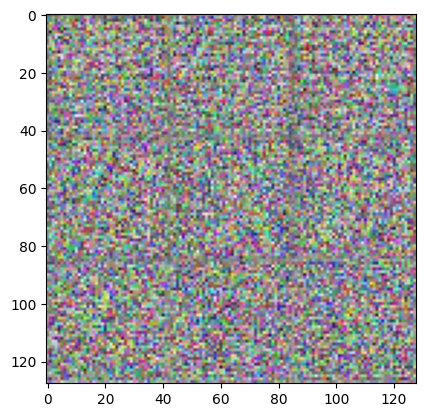

In [48]:
plt.imshow(img.detach().numpy(), cmap="gray")